In [2]:
#allow for autoreload of packages
%load_ext autoreload
%autoreload 2

In [3]:
import os
from getpass import getpass

from dotenv import load_dotenv

import pandas as pd

import fresh
import recycle
from iqm.qiskit_iqm import IQMProvider
from iqm.qiskit_iqm import IQMFakeApollo  # 20-qubit crystal fake backend, for offline testing

/home/doh6/.pyenv/versions/3.12.2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
b = IQMProvider("https://fiqci-qc20.aalto.fi/", quantum_computer="radiance20").get_backend()
name = b.index_to_qubit_name
print({i: name(i) for i in range(b.num_qubits)})
edges = sorted({tuple(sorted(e)) for e in b.coupling_map.get_edges()})
print("edges by name:", [(name(a), name(c)) for a, c in edges])
for q in (8,):
    print(f"index {q} = {name(q)}, neighbours:", [name(x) for x in sorted(b.coupling_map.neighbors(q))])
print("run1/run2 data qubits [9,7,3,13] =", [name(i) for i in (9,7,3,13)])



{0: 'QB1', 1: 'QB2', 2: 'QB3', 3: 'QB5', 4: 'QB6', 5: 'QB7', 6: 'QB8', 7: 'QB9', 8: 'QB10', 9: 'QB11', 10: 'QB12', 11: 'QB13', 12: 'QB14', 13: 'QB15', 14: 'QB16', 15: 'QB17', 16: 'QB18', 17: 'QB19', 18: 'QB20'}
edges by name: [('QB1', 'QB2'), ('QB2', 'QB5'), ('QB3', 'QB8'), ('QB5', 'QB6'), ('QB5', 'QB10'), ('QB6', 'QB7'), ('QB7', 'QB12'), ('QB8', 'QB9'), ('QB8', 'QB13'), ('QB9', 'QB10'), ('QB9', 'QB14'), ('QB10', 'QB11'), ('QB10', 'QB15'), ('QB11', 'QB12'), ('QB11', 'QB16'), ('QB12', 'QB17'), ('QB13', 'QB14'), ('QB14', 'QB15'), ('QB14', 'QB18'), ('QB15', 'QB16'), ('QB15', 'QB19'), ('QB16', 'QB17'), ('QB16', 'QB20'), ('QB18', 'QB19'), ('QB19', 'QB20')]
index 8 = QB10, neighbours: ['QB5', 'QB9', 'QB11', 'QB15']
run1/run2 data qubits [9,7,3,13] = ['QB11', 'QB9', 'QB5', 'QB15']


# Settings

Raw counts of every job are saved as JSON in `DATA_DIR` (one file per strategy / optimization level / repetition depth, with job id, timestamp and qubit layout).
If a file already exists it is loaded instead of re-running, so an interrupted run can be resumed and the analysis can be re-run without the QPU.
Use a new `DATA_DIR` for a new independent run.

`DATA_QUBITS` pins the 4 data qubits to the same physical qubits in both strategies and at every optimization level. Ancillas go on the free qubits closest to them (FRESH ancilla 1 and the RECYCLE ancilla share the same qubit).

In [22]:
SHOTS = 100_000
ITERS = 7                     # plaquette repetitions n = 1..ITERS
OPT_LEVELS = [0, 1, 2]
# run1: transpiler chose qubits freely; run2-run4: pinned data qubits, unseeded (random) routing
DATA_DIR = "data/q20/run4"
SEED = 1234                         # seed_transpiler: same SWAP routing every time a circuit is compiled (None = random)
# Qiskit indices, not QB labels: index i = QB(i+1) for i <= 2, QB(i+2) for i >= 3 (QB4 is disabled)
DATA_QUBITS = [9, 7, 3, 13]         # = QB11, QB9, QB5, QB15; same for FRESH and RECYCLE (ancilla index 8 = QB10 is adjacent to all four)

# Retrieve backend

In [23]:
load_dotenv()
auth = {} if os.environ.get("IQM_TOKEN") else {"token": getpass("IQM Server token")}
provider = IQMProvider("https://fiqci-qc20.aalto.fi/", quantum_computer="radiance20", **auth)
backend = provider.get_backend()
#backend = IQMFakeApollo()
print(f"Selected backend: {backend.name}, {backend.num_qubits} qubits")

Selected backend: radiance20, 19 qubits


# FRESH

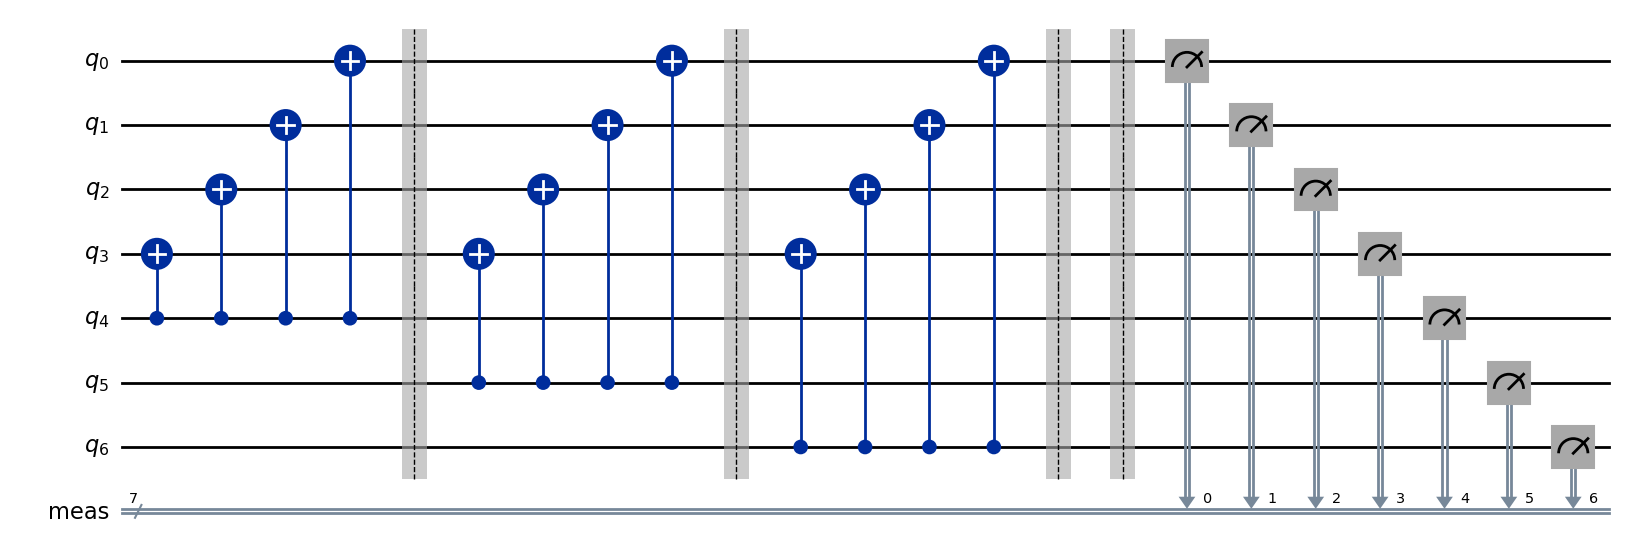

In [7]:
fresh.generate_circuit(n=3).draw("mpl")

In [24]:
results_fr = {}
for opt in OPT_LEVELS:
    results_fr[opt] = fresh.get_ancilla_probabilities(iters=ITERS,
                                                      shots=SHOTS,
                                                      backend=backend,
                                                      optimization_level=opt,
                                                      save_dir=DATA_DIR,
                                                      data_qubits=DATA_QUBITS,
                                                      seed_transpiler=SEED)
    print(opt, results_fr[opt])

radiance20
radiance20
radiance20
radiance20


Progress in queue:   0%|          | 0/1 [00:32<?, ?it/s]


radiance20
radiance20
radiance20
0 [[0.003], [0.0616, 0.0255], [0.0869, 0.072, 0.0303], [0.0684, 0.0485, 0.0521, 0.0407], [0.0785, 0.0773, 0.0672, 0.2334, 0.0636], [0.0542, 0.0384, 0.0527, 0.1779, 0.2428, 0.0479], [0.055, 0.0382, 0.0576, 0.1915, 0.2395, 0.1426, 0.073]]
radiance20
radiance20
radiance20


Progress in queue:   0%|          | 0/1 [00:32<?, ?it/s]


radiance20
radiance20
radiance20
radiance20


...

radiance20
radiance20


Progress in queue:   0%|          | 0/1 [00:31<?, ?it/s]


radiance20
radiance20


Progress in queue:   0%|          | 0/1 [00:32<?, ?it/s]


radiance20
2 [[0.0033], [0.0391, 0.0149], [0.0393, 0.0149, 0.0229], [0.114, 0.0451, 0.0199, 0.0304], [0.038, 0.0767, 0.0661, 0.072, 0.051], [0.1142, 0.0021, 0.0203, 0.1482, 0.0753, 0.0524], [0.1101, 0.0019, 0.0209, 0.118, 0.0776, 0.0557, 0.0496]]


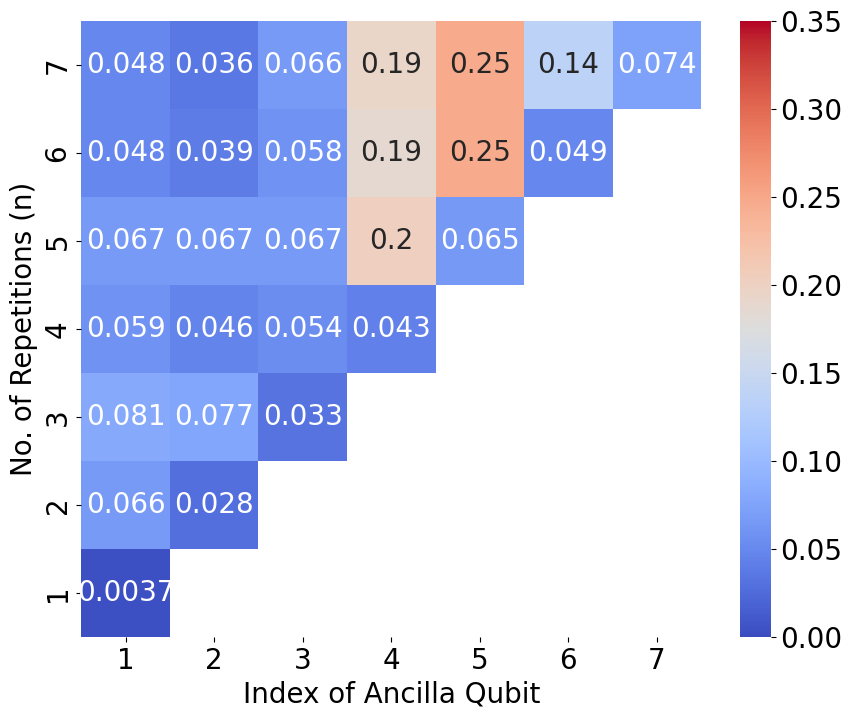

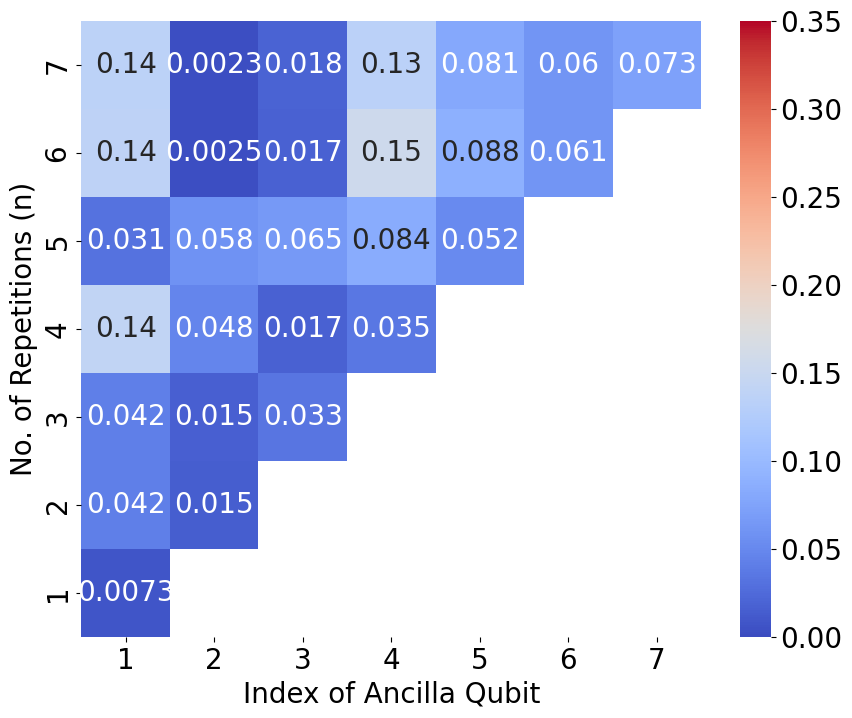

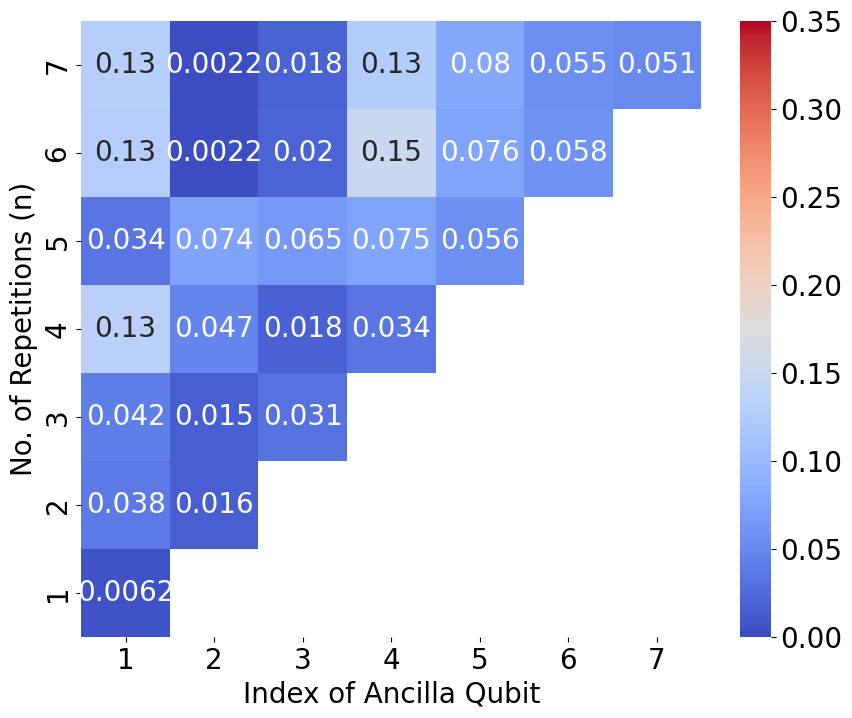

In [9]:
for opt in OPT_LEVELS:
    fresh.plot_heatmap(results_fr[opt], opt)

# RECYCLE

In [ ]:
results_re = {}
for opt in OPT_LEVELS:
    results_re[opt] = recycle.get_ancilla_probabilities(iters=ITERS,
                                                        shots=SHOTS,
                                                        backend=backend,
                                                        optimization_level=opt,
                                                        save_dir=DATA_DIR,
                                                      data_qubits=DATA_QUBITS,
                                                      seed_transpiler=SEED)
    print(opt, results_re[opt])

radiance20


radiance20
radiance20
radiance20


Progress in queue:   0%|          | 0/1 [00:32<?, ?it/s]


radiance20
radiance20


Progress in queue:   0%|          | 0/1 [00:32<?, ?it/s]


radiance20


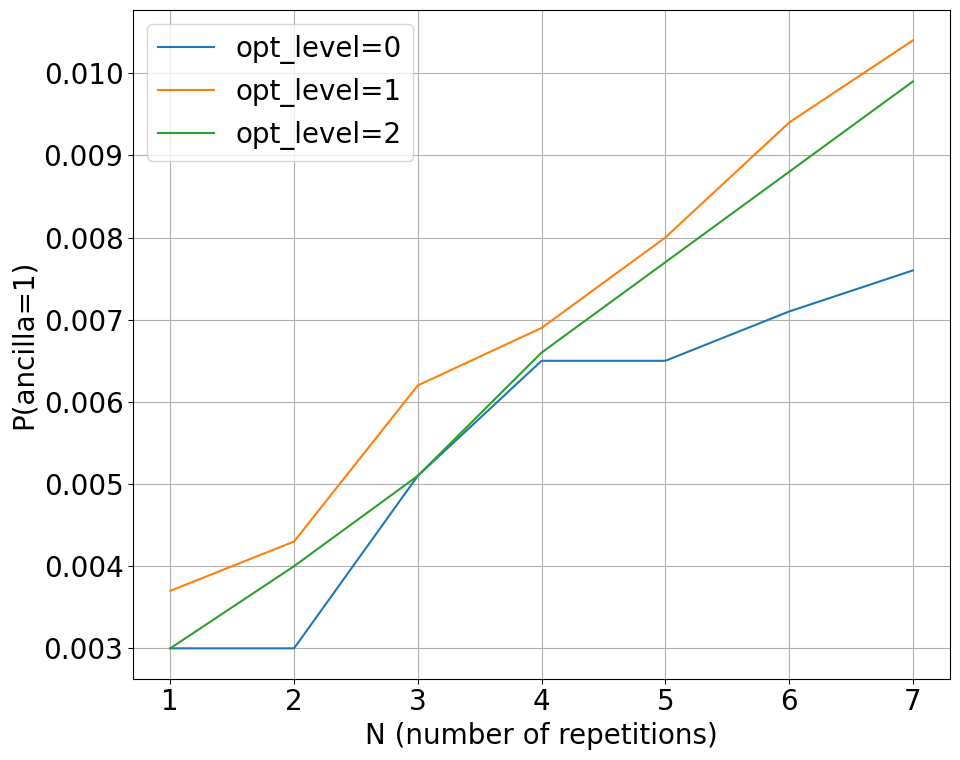

In [16]:
recycle.plot_all_results(results_re[0], results_re[1], results_re[2], ITERS)

# Error rates

In [21]:
n = ITERS
rows = []
for opt in OPT_LEVELS:
    corre = recycle.corr_err(results_fr[opt], results_re[opt], n)          # Eq. (4)
    rows.append({
        "opt_level": opt,
        "plaq_F Eq.12 (%)": fresh.plag_error_rate(results_fr[opt], n, window=True) * 100,
        "plaq_F Eq.6 (%)": fresh.plag_error_rate(results_fr[opt], n, window=False) * 100,
        "plaq_R Eq.8 (%)": recycle.plag_error_rate(corre, results_re[opt], n) * 100,
        "corre Eq.4 (%)": corre * 100,
    })

table = pd.DataFrame(rows).set_index("opt_level").round(2)
table

,plaq_F Eq.12 (%),plaq_F Eq.6 (%),plaq_R Eq.8 (%),corre Eq.4 (%)
opt_level,,,,
0,0.87,1.13,1.36,-1.29
1,0.97,0.95,0.98,-0.87
2,0.86,0.79,1.00,-0.88
